# Customer Support Ticket Analysis

## Project Goal

This project simulates the **feedback-to-data flywheel** scenario: an ML model (or agent) is deployed in production, users interact with it, and support tickets accumulate as feedback. The goal is to apply **unsupervised clustering** to discover patterns in this feedback data.

Two directions of analysis:

**1. Ticket Clustering** — group tickets by problem description (text) to find recurring error/complaint patterns.
- Answers: **"WHAT problems occur?"**
- Main feature: Ticket Description (via SBERT/TF-IDF embeddings)

**2. Customer Segmentation** — group customers by behavioral features (ticket frequency, types, satisfaction, demographics) to find user segments.
- Answers: **"WHO experiences these problems?"**
- Main features: structured data (ticket_count, type distribution, satisfaction, age, etc.)
- Ticket Description is **not used** here — only numeric and categorical features

Together these two directions give a full picture for the next training iteration: which problems to fix (ticket clusters) and which user groups to prioritize (customer segments).

In [1]:
# imports
import sys
sys.path.append("../src")

from data_loader import load_row
import matplotlib.pyplot as plt 
import seaborn as sns

## 1. Setup & Load Data

In [2]:
df = load_row(path="../data/customer_support_tickets.csv")
df.head(5)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 2. Dataset Overview

In [3]:
# count records
len(df.values)

8469

In [4]:
# count features
len(df.columns)

17

In [5]:
# dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [6]:
# feature types

feat_str_count = len(df.select_dtypes(include="str").columns)
feat_num_count = len(df.select_dtypes(include="number").columns)
print(f"String type = {feat_str_count}")
print(f"Numeric type = {feat_num_count}")

String type = 14
Numeric type = 3


In [7]:
# dataset describe numeric features

df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [8]:
# missings

df.isna().mean() * 100

Ticket ID                        0.000000
Customer Name                    0.000000
Customer Email                   0.000000
Customer Age                     0.000000
Customer Gender                  0.000000
Product Purchased                0.000000
Date of Purchase                 0.000000
Ticket Type                      0.000000
Ticket Subject                   0.000000
Ticket Description               0.000000
Ticket Status                    0.000000
Resolution                      67.304286
Ticket Priority                  0.000000
Ticket Channel                   0.000000
First Response Time             33.286102
Time to Resolution              67.304286
Customer Satisfaction Rating    67.304286
dtype: float64

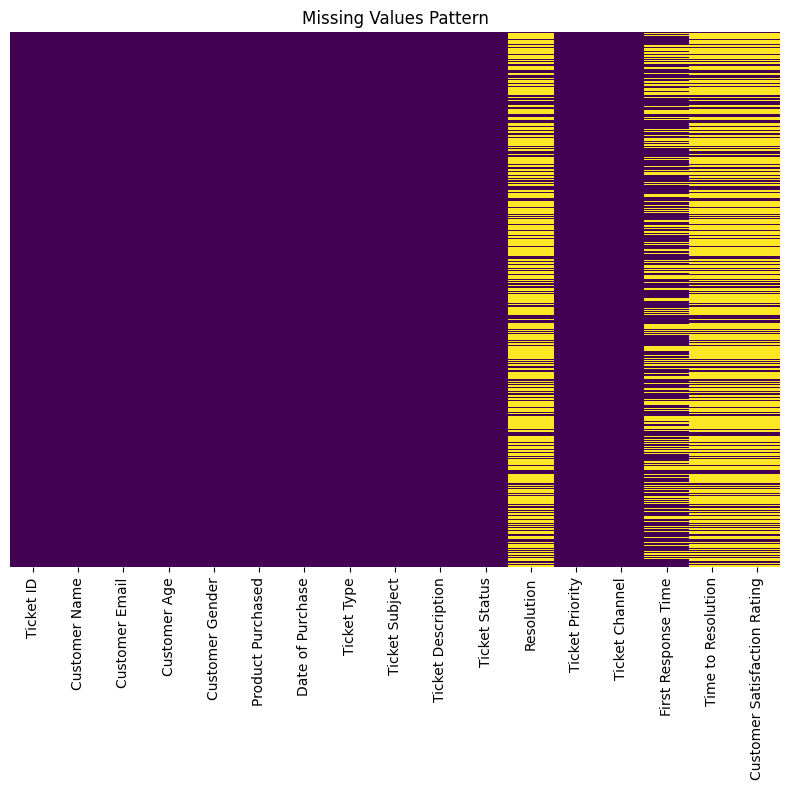

In [9]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Pattern")
plt.tight_layout()
plt.show()

In [ ]:
# missing values heatmap — only columns with nulls, sorted to reveal pattern
cols_with_na = df.columns[df.isna().any()]
df_na = df[cols_with_na].sort_values(by=list(cols_with_na))

plt.figure(figsize=(8, 6))
sns.heatmap(df_na.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Pattern (only columns with nulls, sorted)")
plt.tight_layout()
plt.show()

In [ ]:
# missing values correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(df[cols_with_na].isna().corr(), annot=True,
            fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Missing Values Correlation")
plt.tight_layout()
plt.show()

**Conclusion — Dataset Overview:**
- Dataset has **8,469 rows** and **17 columns** (14 string, 3 numeric)
- Three columns have ~67% missing values: Resolution, Time to Resolution, Customer Satisfaction Rating. These are missing **together** — they only exist for closed tickets. This is not random, it is a structural pattern (MAR — Missing At Random, depends on Ticket Status)
- First Response Time has ~33% missing — a separate pattern
- These columns with many missing values are **not useful as clustering features**. We will drop Resolution (it contains garbage text) and not rely on Time to Resolution or Satisfaction for the main clustering task

## 3. Duplicate Check

In [10]:
# full duplicate rows
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes} ({full_dupes / len(df) * 100:.2f}%)")

# duplicates by Ticket Description (main clustering feature)
desc_dupes = df["Ticket Description"].duplicated().sum()
print(f"Duplicate Ticket Descriptions: {desc_dupes} ({desc_dupes / len(df) * 100:.2f}%)")
print(f"Unique Ticket Descriptions: {df['Ticket Description'].nunique()}")

# duplicates by Ticket ID (should be unique)
id_dupes = df["Ticket ID"].duplicated().sum()
print(f"Duplicate Ticket IDs: {id_dupes}")

# show examples of duplicate descriptions if any
if desc_dupes > 0:
    dup_desc = df[df["Ticket Description"].duplicated(keep=False)]
    top_dup = (dup_desc.groupby("Ticket Description")
               .size()
               .sort_values(ascending=False)
               .head(5))
    print(f"\nTop 5 most repeated descriptions (count):")
    for desc, count in top_dup.items():
        print(f"  [{count}x] {desc[:100]}...") # type: ignore

Full duplicate rows: 0 (0.00%)
Duplicate Ticket Descriptions: 392 (4.63%)
Unique Ticket Descriptions: 8077
Duplicate Ticket IDs: 0

Top 5 most repeated descriptions (count):
  [25x] I'm having an issue with the {product_purchased}. Please assist. This problem started occurring afte...
  [25x] I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possib...
  [25x] I'm having an issue with the {product_purchased}. Please assist. I'm concerned about the security of...
  [24x] I'm having an issue with the {product_purchased}. Please assist. I've already contacted customer sup...
  [24x] I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error messa...


**Conclusion — Duplicate Check:**
- No full duplicate rows — every row is unique when we look at all 17 columns
- But ~4.6% of Ticket Descriptions are duplicated. This means some tickets have the same text but different customers/products. This is expected for synthetic data — the text was generated from templates
- For clustering, this is fine. Duplicate texts will just land in the same cluster. No need to remove them

## 4. Feature Distributions

### 4.1 Categorical features

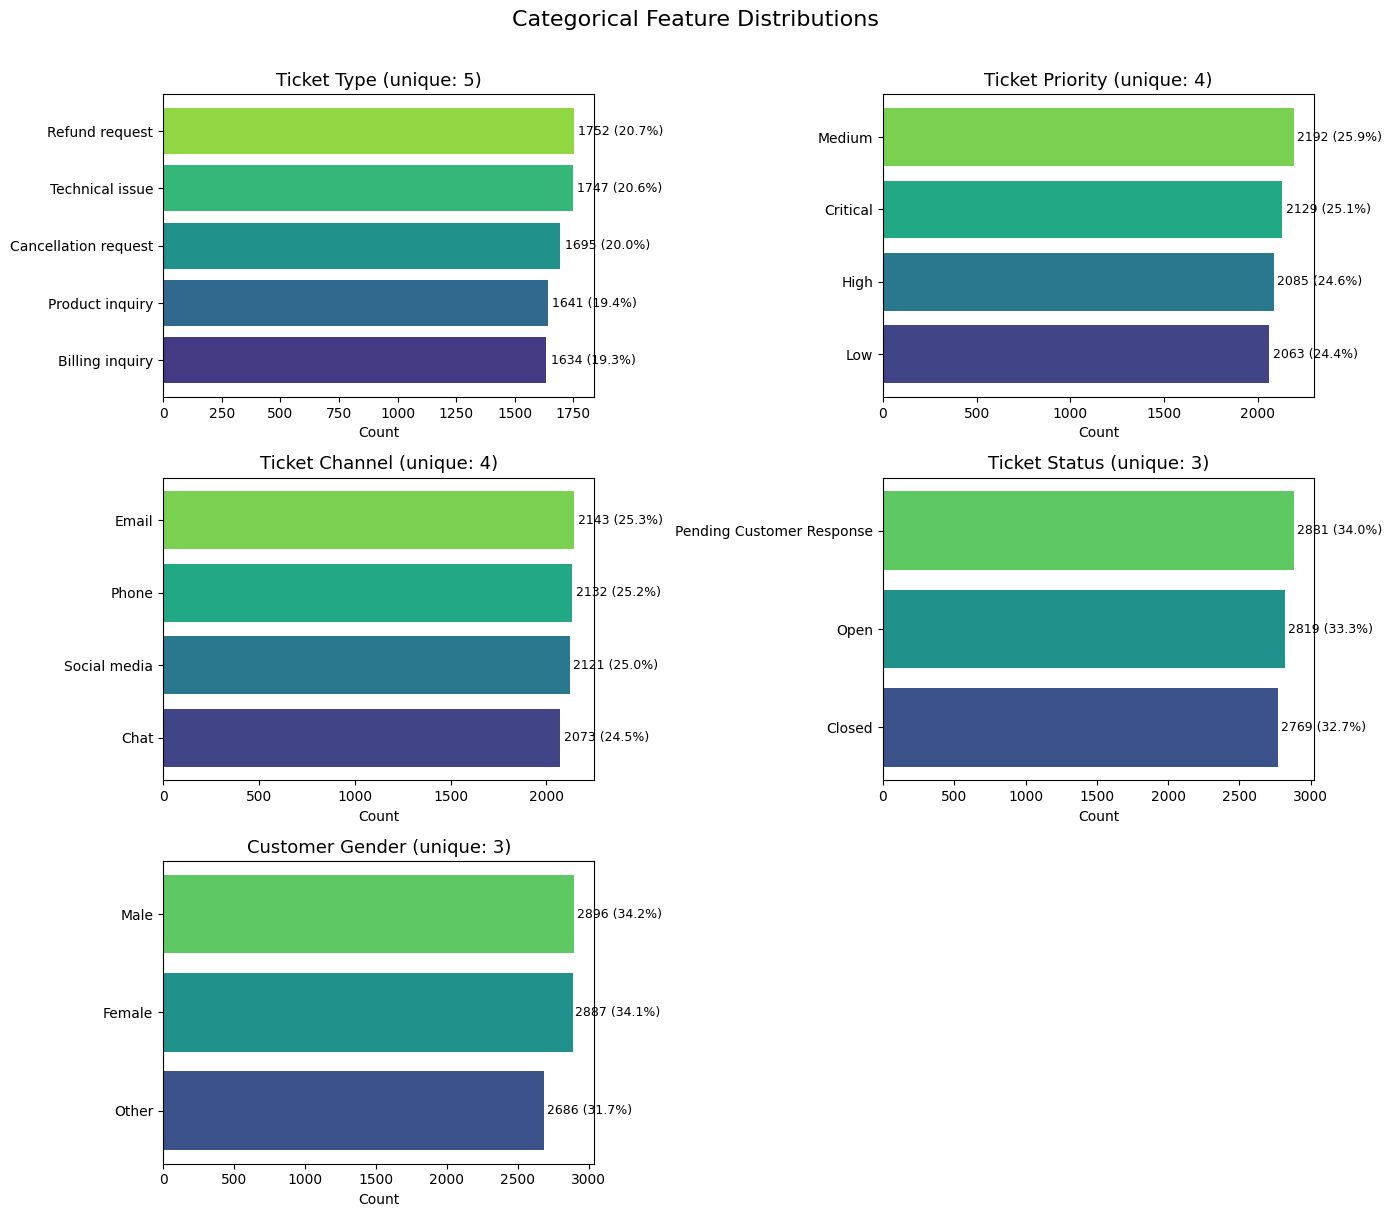

In [12]:
categorical_small = [
    "Ticket Type", "Ticket Priority", "Ticket Channel",
    "Ticket Status", "Customer Gender"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_small):
    counts = df[col].value_counts().sort_values()
    ax = axes[i]
    bars = ax.barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts)))
    ax.set_title(f"{col} (unique: {len(counts)})", fontsize=13)
    ax.set_xlabel("Count")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                f"{val} ({val / len(df) * 100:.1f}%)", va="center", fontsize=9)

axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

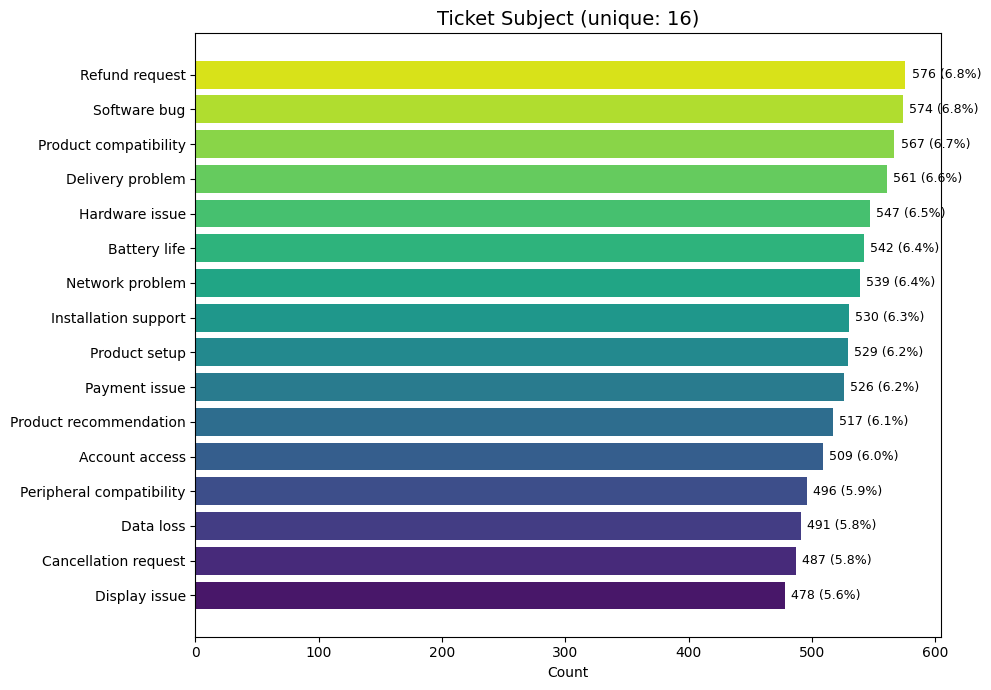

In [ ]:
# Ticket Subject distribution (16 categories — separate plot)
counts = df["Ticket Subject"].value_counts().sort_values()

plt.figure(figsize=(10, 7))
bars = plt.barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts))) # type: ignore
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"{val} ({val / len(df) * 100:.1f}%)", va="center", fontsize=9)
plt.title(f"Ticket Subject (unique: {len(counts)})", fontsize=14)
plt.xlabel("Count")
plt.tight_layout()
plt.show()

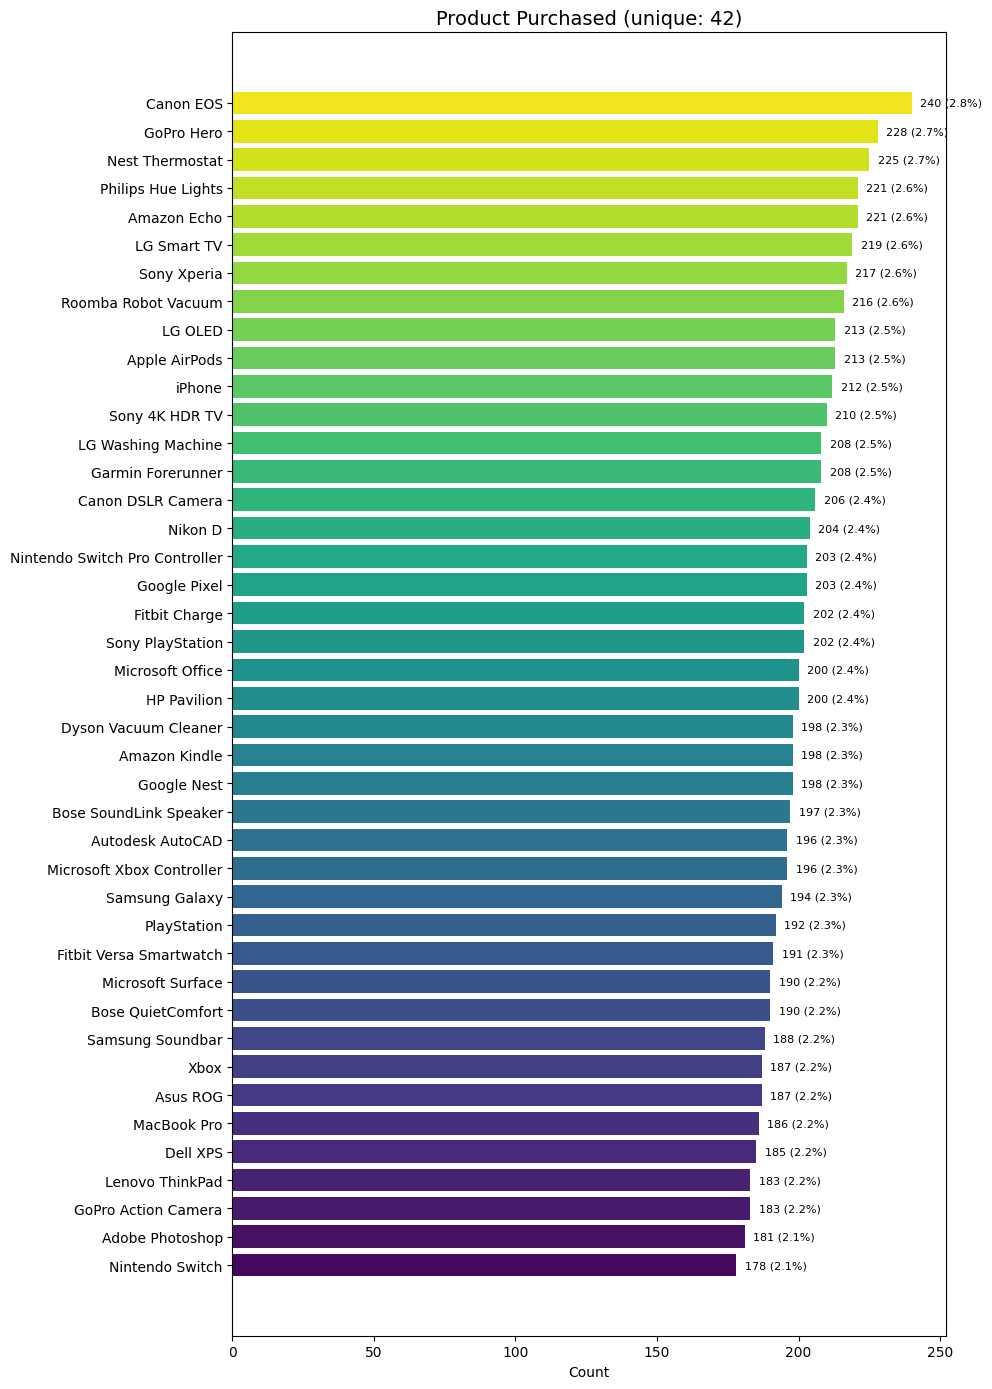

In [ ]:
# Product Purchased distribution (42 categories — separate plot)
counts = df["Product Purchased"].value_counts().sort_values()

plt.figure(figsize=(10, 14))
bars = plt.barh(counts.index, counts.values, color=sns.color_palette("viridis", len(counts))) # type: ignore
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
             f"{val} ({val / len(df) * 100:.1f}%)", va="center", fontsize=8)
plt.title(f"Product Purchased (unique: {len(counts)})", fontsize=14)
plt.xlabel("Count")
plt.tight_layout()
plt.show()

**Conclusion — Categorical Features:**
- All categorical features are **well-balanced** — no single category dominates. This is typical for synthetic data
- Ticket Type has 5 categories, Ticket Subject has 16, Product Purchased has 42 — all roughly equal in size
- Priority, Channel, Status, Gender — also balanced (3-4 categories each)
- Since categories are balanced, clustering results won't be biased by class imbalance. If we see uneven clusters later — that means the algorithm found real structure, not just reflected existing category sizes

### 4.2 Numeric features

In [ ]:
# Distributions — histograms with KDE
numeric_cols = ["Customer Age", "Customer Satisfaction Rating"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, numeric_cols):
    data = df[col].dropna()
    ax.hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.7, density=True)
    data.plot.kde(ax=ax, color="darkred", linewidth=2)
    ax.set_title(f"{col} (n={len(data)}, mean={data.mean():.1f}, std={data.std():.1f})", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.suptitle("Numeric Feature Distributions", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# Outliers — boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, numeric_cols):
    data = df[col].dropna()
    sns.boxplot(x=data, ax=ax, color="steelblue")
    ax.set_title(f"{col} — Boxplot", fontsize=12)
    ax.set_xlabel(col)

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data < lower) | (data > upper)]
    ax.text(0.98, 0.95, f"IQR: {iqr:.1f}\nBounds: [{lower:.1f}, {upper:.1f}]\nOutliers: {len(outliers)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.suptitle("Outlier Detection (IQR method)", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation between numeric features
numeric_df = df[["Customer Age", "Customer Satisfaction Rating"]].dropna()

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True)
plt.title("Numeric Features Correlation", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Pearson correlation (Age vs Satisfaction): {numeric_df.corr().iloc[0, 1]:.4f}")
print(f"Sample size for correlation: {len(numeric_df)} (only rows where both values present)")

**Conclusion — Numeric Features:**
- Customer Age: ranges from 18 to 70, roughly uniform distribution. No outliers. Not very useful for ticket clustering, but useful for customer segmentation
- Customer Satisfaction Rating: ranges 1-5, roughly uniform, available only for closed tickets (~33% of data). Not a clustering feature — it is a **result** of the support process, not a description of the problem
- No meaningful correlation between Age and Satisfaction — they are independent
- For ticket clustering we will not use these numeric features. They will be useful later in customer segmentation (Phase 7)

### 4.3 Text analysis (Ticket Description)

In [ ]:
# Description length — characters and words
df["desc_char_len"] = df["Ticket Description"].str.len()
df["desc_word_count"] = df["Ticket Description"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes,
                           ["desc_char_len", "desc_word_count"],
                           ["Character Length", "Word Count"]):
    data = df[col]
    ax.hist(data, bins=40, color="steelblue", edgecolor="white", alpha=0.7)
    ax.axvline(data.mean(), color="darkred", linestyle="--", label=f"mean={data.mean():.0f}")
    ax.axvline(data.median(), color="orange", linestyle="--", label=f"median={data.median():.0f}")
    ax.set_title(f"Ticket Description — {label}", fontsize=13)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Characters: min={df['desc_char_len'].min()}, max={df['desc_char_len'].max()}, "
      f"mean={df['desc_char_len'].mean():.0f}, std={df['desc_char_len'].std():.0f}")
print(f"Words: min={df['desc_word_count'].min()}, max={df['desc_word_count'].max()}, "
      f"mean={df['desc_word_count'].mean():.0f}, std={df['desc_word_count'].std():.0f}")

In [ ]:
# Most frequent words and bigrams (after removing stop words)
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ngram, title in zip(axes,
                              [(1, 1), (2, 2)],
                              ["Top 20 Unigrams", "Top 20 Bigrams"]):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram, max_features=20)
    counts = vec.fit_transform(df["Ticket Description"])
    freq = counts.sum(axis=0).A1 # type: ignore
    terms = vec.get_feature_names_out()

    sorted_idx = freq.argsort()
    ax.barh(terms[sorted_idx], freq[sorted_idx], color="steelblue")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# Template variables — check for {product_purchased} pattern
template_count = df["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True).sum()
print(f"Descriptions containing '{{product_purchased}}': {template_count} / {len(df)} ({template_count / len(df) * 100:.1f}%)")

# Detect common opening patterns
openings = df["Ticket Description"].str[:50].value_counts().head(10)
print(f"\nTop 10 opening phrases (first 50 chars):")
for text, count in openings.items():
    print(f"  [{count:>4}x] {text}...")

In [ ]:
# Sample descriptions — read 15 examples to understand text structure
samples = df["Ticket Description"].sample(15, random_state=42)
for i, (idx, text) in enumerate(samples.items(), 1):
    print(f"--- Example {i} (row {idx}) ---")
    print(text)
    print()

**Conclusion — Text Analysis:**
- All 8,469 descriptions contain the template variable `{product_purchased}` — it was never substituted with the actual product name. **We must fix this in preprocessing** before creating embeddings, otherwise the model won't know which product the ticket is about
- Descriptions are short (~40-60 words). There are ~10 common opening templates ("I'm having an issue with...", "I'm facing a problem with..."). The middle part contains noise filler, the end has a specific complaint
- Top unigrams/bigrams show common support keywords: "issue", "problem", "product", "help", etc.
- **Key decision for clustering**: Ticket Description is our main feature. We need to (1) substitute `{product_purchased}`, (2) use SBERT embeddings which handle noisy short texts better than TF-IDF

## 5. Feature Relationships

### 5.1 Cross-tabulations

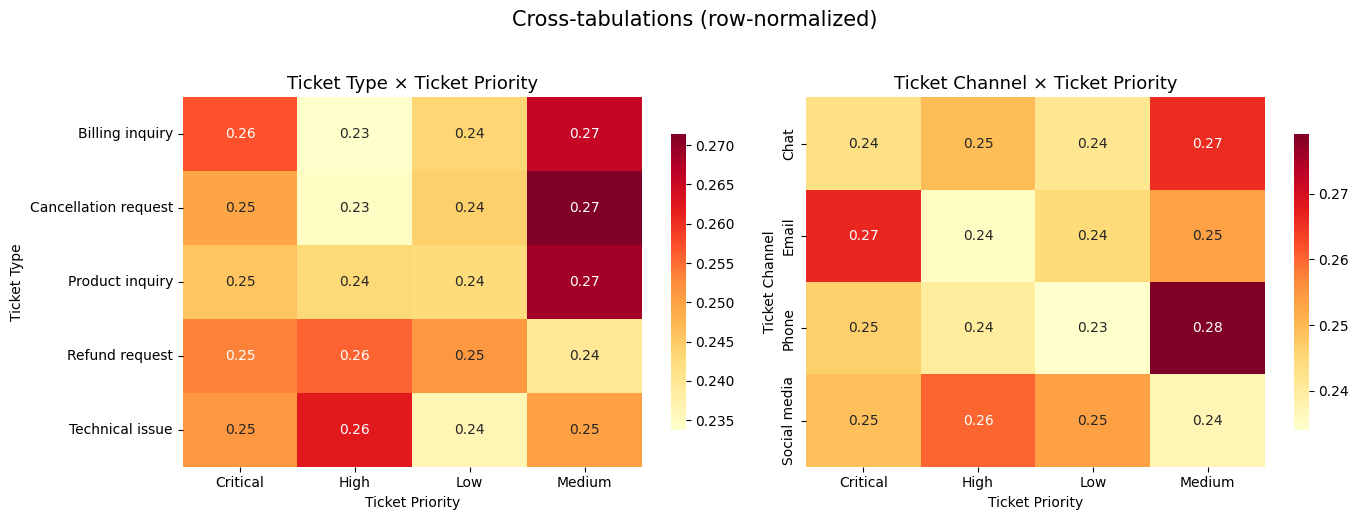

In [17]:
import pandas as pd

# Type × Priority and Channel × Priority (compact categories)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (row, col) in zip(axes, [("Ticket Type", "Ticket Priority"),
                                   ("Ticket Channel", "Ticket Priority")]):
    ct = pd.crosstab(df[row], df[col], normalize="index")
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"{row} × {col}", fontsize=13)

plt.suptitle("Cross-tabulations (row-normalized)", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

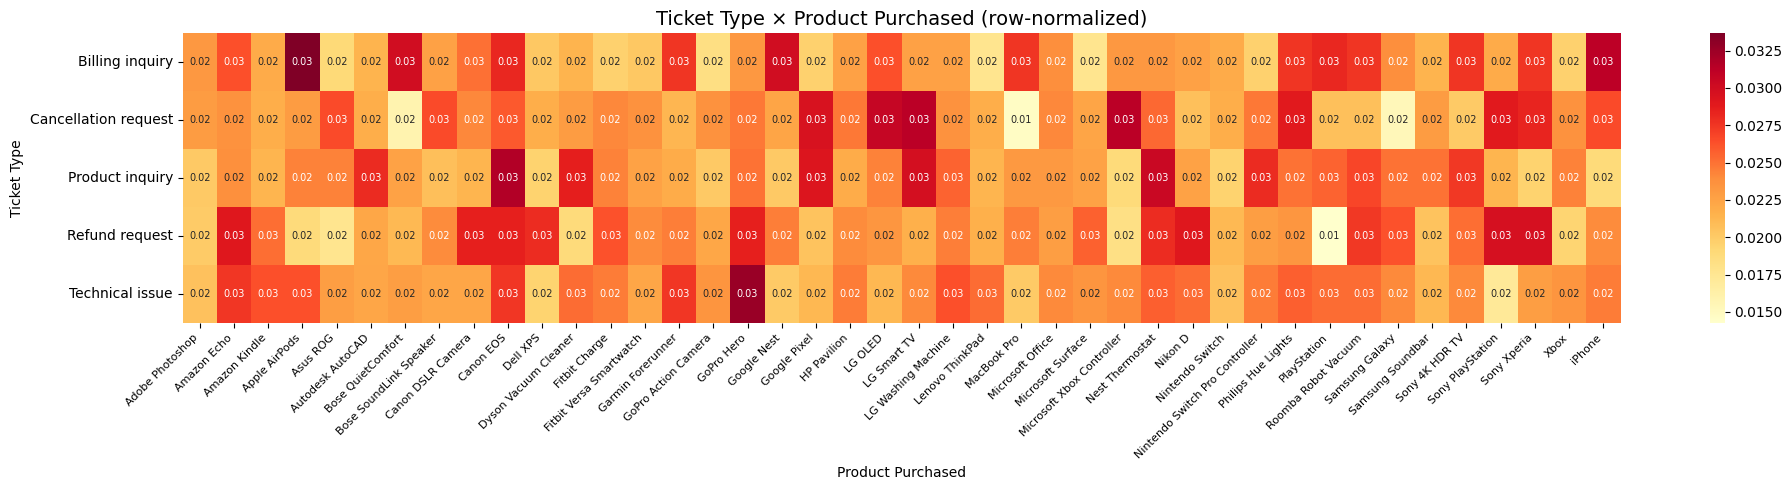

In [18]:
# Type × Product (5 × 42 — large heatmap, separate plot)
ct = pd.crosstab(df["Ticket Type"], df["Product Purchased"], normalize="index")

plt.figure(figsize=(20, 5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", annot_kws={"fontsize": 7})
plt.title("Ticket Type × Product Purchased (row-normalized)", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

**Takeaways — Cross-tabulations:**
- Type × Priority, Channel × Priority — values are almost the same across all cells (~0.25 each). This means categories are **independent** of each other. Knowing the ticket type tells us nothing about its priority, and vice versa
- Type × Product — also near-uniform. Every product has roughly the same mix of ticket types
- This confirms the data is **synthetic** — in real production data, you would expect some products to have more technical issues, or critical tickets to come more through phone. Here everything is random
- For clustering: we should not expect categorical features alone to separate tickets into meaningful groups. The **text** is where the signal is

### 5.2 Satisfaction vs Priority / Type

/var/folders/xd/5ptrhl_s5t14mgdrv48cvm9h0000gn/T/ipykernel_8922/1745130257.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sat, x="Ticket Priority", y="Customer Satisfaction Rating",
/var/folders/xd/5ptrhl_s5t14mgdrv48cvm9h0000gn/T/ipykernel_8922/1745130257.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sat, x="Ticket Type", y="Customer Satisfaction Rating",


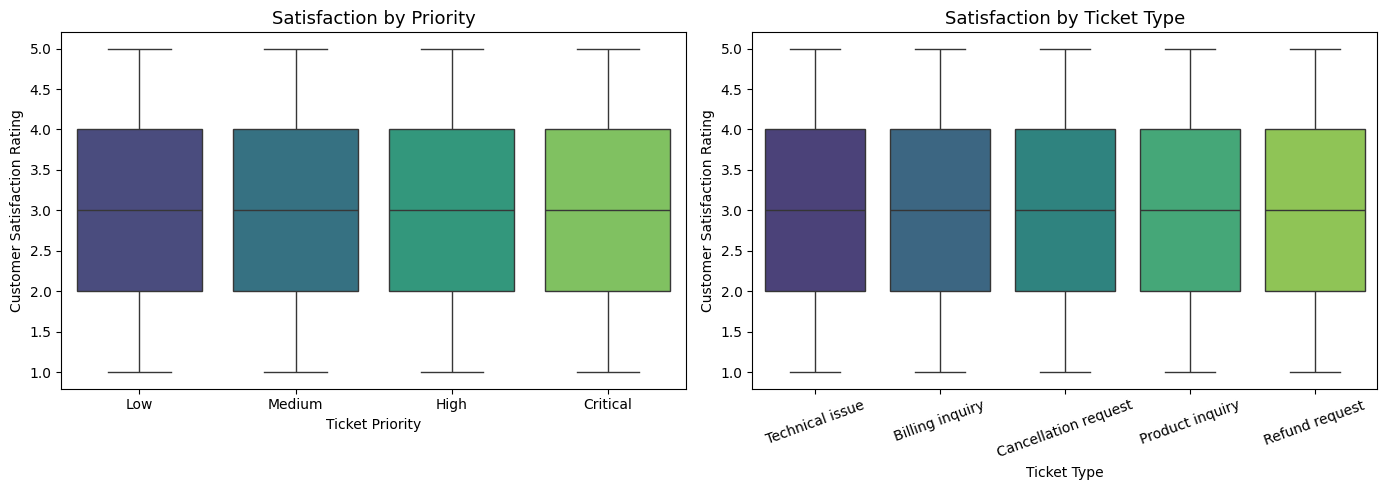

Mean Satisfaction by Priority:
Ticket Priority
Low         3.052795
Medium      2.976945
High        2.982979
Critical    2.958678

Mean Satisfaction by Ticket Type:
Ticket Type
Billing inquiry         3.027574
Cancellation request    3.029070
Product inquiry         3.016886
Refund request          2.934564
Technical issue         2.958621


In [26]:
# Satisfaction vs Priority / Satisfaction vs Type
df_sat = df.dropna(subset=["Customer Satisfaction Rating"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_sat, x="Ticket Priority", y="Customer Satisfaction Rating",
            order=["Low", "Medium", "High", "Critical"], ax=axes[0], palette="viridis")
axes[0].set_title("Satisfaction by Priority", fontsize=13)

sns.boxplot(data=df_sat, x="Ticket Type", y="Customer Satisfaction Rating",
            ax=axes[1], palette="viridis")
axes[1].set_title("Satisfaction by Ticket Type", fontsize=13)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Mean satisfaction per group
print("Mean Satisfaction by Priority:")
print(df_sat.groupby("Ticket Priority")["Customer Satisfaction Rating"].mean()
      .reindex(["Low", "Medium", "High", "Critical"]).to_string())
print(f"\nMean Satisfaction by Ticket Type:")
print(df_sat.groupby("Ticket Type")["Customer Satisfaction Rating"].mean().to_string())

**Takeaways — Satisfaction vs Priority / Type:**
- Mean satisfaction is roughly the same (~3.0) across all priorities and all ticket types
- No clear pattern: critical tickets are not less satisfied than low-priority ones
- Again confirms synthetic data — in real data, you would expect lower satisfaction for critical/unresolved issues
- Satisfaction will not help separate clusters of tickets, but can be useful for **customer segmentation** to identify unhappy user groups

### 5.3 Tickets per customer

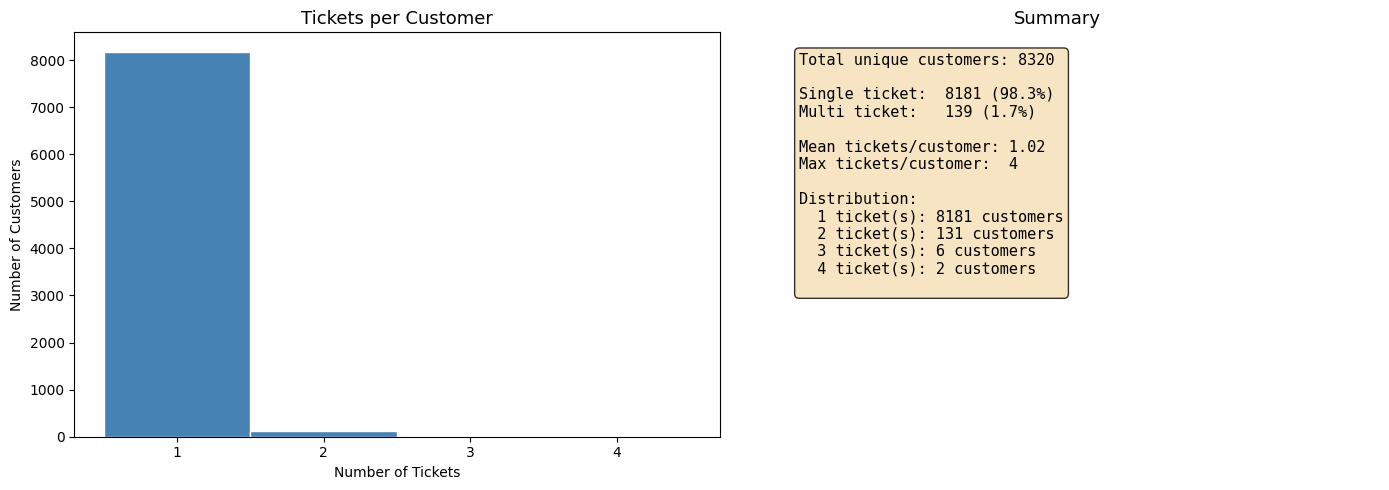

In [27]:
# Ticket count per customer
tickets_per_customer = df.groupby("Customer Email").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(tickets_per_customer, bins=range(1, tickets_per_customer.max() + 2),
             color="steelblue", edgecolor="white", align="left")
axes[0].set_title("Tickets per Customer", fontsize=13)
axes[0].set_xlabel("Number of Tickets")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticks(range(1, tickets_per_customer.max() + 1))

# Summary stats
axes[1].axis("off")
total_customers = len(tickets_per_customer)
single_ticket = (tickets_per_customer == 1).sum()
multi_ticket = (tickets_per_customer > 1).sum()
summary = (
    f"Total unique customers: {total_customers}\n\n"
    f"Single ticket:  {single_ticket} ({single_ticket / total_customers * 100:.1f}%)\n"
    f"Multi ticket:   {multi_ticket} ({multi_ticket / total_customers * 100:.1f}%)\n\n"
    f"Mean tickets/customer: {tickets_per_customer.mean():.2f}\n"
    f"Max tickets/customer:  {tickets_per_customer.max()}\n\n"
    f"Distribution:\n"
)
for n_tickets, count in tickets_per_customer.value_counts().sort_index().items():
    summary += f"  {n_tickets} ticket(s): {count} customers\n"
axes[1].text(0.1, 0.95, summary, transform=axes[1].transAxes, fontsize=11,
             verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
axes[1].set_title("Summary", fontsize=13)

plt.tight_layout()
plt.show()

**Takeaways — Tickets per Customer:**
- Shows how many tickets each customer created. Most customers have 1 ticket, some have 2-3
- This distribution matters for **customer segmentation** (Phase 7): customers with many tickets behave differently than one-time users
- For **ticket clustering** (our main task) this is not directly useful — we cluster tickets, not customers

## 6. EDA Summary

**What we learned:**
1. The dataset has 8,469 support tickets with 17 features. Data is clean — no full duplicates, core columns have no missing values
2. The data is **synthetic** — all categorical features are uniformly distributed and independent of each other. In real data, we would see patterns (e.g., some products cause more technical issues)
3. Missing values follow a structural pattern: Resolution, Time to Resolution, and Satisfaction are only present for closed tickets

**What matters for ticket clustering:**
- **Ticket Description is the only feature that carries real signal** for finding error/complaint patterns
- All descriptions contain `{product_purchased}` placeholder — must be substituted before embedding
- Categorical features (Type, Subject, Priority) are balanced and independent — they won't help separate clusters on their own
- We will use Ticket Subject (16 categories) as a **validation label** after clustering, not as an input feature

**What matters for customer segmentation:**
- Customer Age, Satisfaction Rating, ticket frequency, ticket types per customer — these structured features will be combined into a customer-level feature vector
- Most customers have 1 ticket, some have 2-3 — enough variance for segmentation

**Next step:** Preprocessing — substitute template variables, clean text, prepare data for embedding